In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading :

In [3]:
airbnb_data = pd.read_csv(filepath_or_buffer='AB_NYC_2019.csv')
airbnb_data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


## 1. Data Integrity :

### i. Checking Data Types :

In [4]:
airbnb_data.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

####   In the given data , the 'last review' column fully consists of dates but in data types it is proided as 'object' . So inorder to get the better result , we cjange the datatype to 'DateTime'

In [5]:
airbnb_data['last_review'] = pd.to_datetime(airbnb_data['last_review'])

In [14]:
airbnb_data.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

#### Now the datatype for last_review is corrected .

### ii. Validate value ranges (price > 0, availability ≤ 365) :

In [26]:
# A listing cannot have zero or negative price.
price_less_than_0 = (airbnb_data['price'] < 0).sum()
print("Price less than zero : ",price_less_than_0)

price_0 = (airbnb_data['price'] == 0).sum()
print("Price equal to zero : ",price_0)

# Availability represents number of days in a year, so it must be between 0 and 365.
availability_mistake = (airbnb_data['availability_365'] > 365).sum()
print("Availability errors : ",availability_mistake)

Price less than zero :  0
Price equal to zero :  11
Availability errors :  0


#### Based on our above operation , we conclude that the price column cotains 11 values equal to 0 which results in error .

In [33]:
airbnb_data[airbnb_data['price'] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaT,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


####       we are going to remove price column with values '0' because 'airbnb' hostings does not have price '0'. This may be occured to wrong entry .But howewer it could affect our result in average mean , etc... So we remove it.

In [37]:
# Table with non-zero price :
non_zero_price = airbnb_data[airbnb_data['price'] > 0]
non_zero_price

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2


#### The above corrected dataset does not contains any price values '0' .

### iii. Checking whether the id is unique .

In [48]:
non_zero_price['id'].is_unique

non_zero_price[non_zero_price.duplicated(subset='id')]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


#### From this , we can ensure that the id values are unique and they do not contain any duplicate values .

### iv. adding a new column to seperate the reviews given and not given .

In [66]:
non_zero_price_1 = non_zero_price.copy()

def reviews_given(row):
    if row['number_of_reviews' ]> 0:
        return 'yes'
    elif row['number_of_reviews'] == 0:
        return 'No'
    else :
        return 'error'
non_zero_price_1['Has_Reviews'] = non_zero_price_1.apply(reviews_given,axis = 1)

In [67]:
non_zero_price_1

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Has_Reviews
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,yes
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,yes
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,No
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,yes
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9,No
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36,No
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27,No
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2,No


## 2. Missing Data Handling : 

### i. Detect missing values :

In [69]:
non_zero_price_1.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                 10051
calculated_host_listings_count        0
availability_365                      0
Has_Reviews                           0
dtype: int64

#### Here the certain columns , contains null values . So inorder to give an better output , we use null handling techniques .

### ii. removing rows with name : 'null'

In [107]:
non_zero_price_1[non_zero_price_1['name'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Has_Reviews
2854,1615764,NaN,6676776,Peter,Manhattan,Battery Park City,40.71239,-74.01620,Entire home/apt,400,1000,0,NaT,NaN,1,362,No
3703,2232600,NaN,11395220,Anna,Manhattan,East Village,40.73215,-73.98821,Entire home/apt,200,1,28,2015-06-08,0.45,1,341,yes
5775,4209595,NaN,20700823,Jesse,Manhattan,Greenwich Village,40.73473,-73.99244,Entire home/apt,225,1,1,2015-01-01,0.02,1,0,yes
5975,4370230,NaN,22686810,Michaël,Manhattan,Nolita,40.72046,-73.99550,Entire home/apt,215,7,5,2016-01-02,0.09,1,0,yes
6269,4581788,NaN,21600904,Lucie,Brooklyn,Williamsburg,40.71370,-73.94378,Private room,150,1,0,NaT,NaN,1,0,No
6567,4756856,NaN,1832442,Carolina,Brooklyn,Bushwick,40.70046,-73.92825,Private room,70,1,0,NaT,NaN,1,0,No
6605,4774658,NaN,24625694,Josh,Manhattan,Washington Heights,40.85198,-73.93108,Private room,40,1,0,NaT,NaN,1,0,No
8841,6782407,NaN,31147528,Huei-Yin,Brooklyn,Williamsburg,40.71354,-73.93882,Private room,45,1,0,NaT,NaN,1,0,No
11963,9325951,NaN,33377685,Jonathan,Manhattan,Hell's Kitchen,40.76436,-73.98573,Entire home/apt,190,4,1,2016-01-05,0.02,1,0,yes
12824,9787590,NaN,50448556,Miguel,Manhattan,Harlem,40.80316,-73.95189,Entire home/apt,300,5,0,NaT,NaN,5,0,No


#### Since many rows contains null values for name column so it will be very hard to analyse , so we better remove the row with names 'null'.

In [89]:
removing_null_names = non_zero_price_1.dropna(subset = 'name')
removing_null_names.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10041
reviews_per_month                 10041
calculated_host_listings_count        0
availability_365                      0
Has_Reviews                           0
dtype: int64

### iii. since 'host_name' column contains 21 null values , we can replace it with 'unknown' since it will be very useful for further upcoming calculation.

In [92]:
data_cleaned = removing_null_names.copy()
data_cleaned['host_name']= data_cleaned['host_name'].fillna('Unknown')
data_cleaned.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10041
reviews_per_month                 10041
calculated_host_listings_count        0
availability_365                      0
Has_Reviews                           0
dtype: int64

#### Now the host_name is fixed .Finally , 'last_review' and 'reviews_per_month' contains 10041 null value but null values in these calculations are to be mentioned as '0' as they are an integer and have zero count.   for eg : A review may have zero or more count .

### iv. fixing reviews columns :

In [99]:
data_cleaned[['last_review','reviews_per_month']] = data_cleaned[['last_review','reviews_per_month']].fillna(0)
data_cleaned.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
Has_Reviews                       0
dtype: int64

#### Finaly all the null values are handled successfully and now we can proceed with the upcoming analysis.

## 3. Duplicate Removal : 

In [106]:
no_of_duplicates = data_cleaned.duplicated().sum()
print("Duplicate Values : ",no_of_duplicates)

Duplicate Values :  0


#### Based on the above calculations , we came to conclude that the dataset does not conatins any duplicated values . So it is safe for us to proceed with the upcoming basis .

## 4. Standardization :

### i. Text (Categorical) Standardization

In [109]:
data_cleaned['room_type'] = data_cleaned['room_type'].str.lower().str.strip()
data_cleaned['neighbourhood_group'] = data_cleaned['neighbourhood_group'].str.title().str.strip()
data_cleaned['neighbourhood'] = data_cleaned['neighbourhood'].str.title().str.strip()

data_cleaned

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Has_Reviews
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,private room,149,1,9,2018-10-19 00:00:00,0.21,6,365,yes
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355,yes
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,private room,150,3,0,0,0.00,1,365,No
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,entire home/apt,89,1,270,2019-07-05 00:00:00,4.64,1,194,yes
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,entire home/apt,80,10,9,2018-11-19 00:00:00,0.10,1,0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,private room,70,2,0,0,0.00,2,9,No
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,private room,40,4,0,0,0.00,2,36,No
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,entire home/apt,115,10,0,0,0.00,1,27,No
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell'S Kitchen,40.75751,-73.99112,shared room,55,1,0,0,0.00,6,2,No


### ii. Date Standardization :

In [110]:
data_cleaned['last_review'] = pd.to_datetime(data_cleaned['last_review'],errors='coerce')

### iii. Unit Consistency Checks :

In [122]:
print("price check : ",(data_cleaned['price'] <= 0).sum())
print("availability check : ",(data_cleaned['availability_365'] > 365).sum())

price check :  0
availability check :  0


#### which means that all the units are correct .

### iv. Numeric Scaling :

In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['price', 'minimum_nights', 'availability_365']

data_cleaned[cols] = scaler.fit_transform(data_cleaned[cols])

#### Numeric scaling puts all numeric features on the same scale so that machine-learning algorithms treat them fairly.

## 5. Outlier Detection :

### i. BoxPlot :

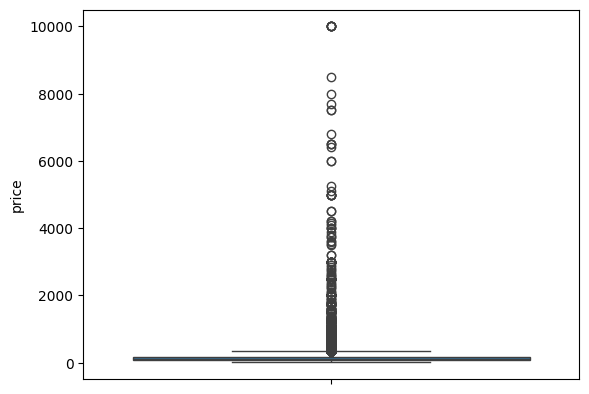

In [134]:
import seaborn as sns
sns.boxplot(data=removing_null_names, y = 'price')

plt.show()

### ii. Removing Outliers :

In [137]:
Q1 = removing_null_names['price'].quantile(0.25)
Q3 = removing_null_names['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers = removing_null_names[(removing_null_names['price'] <= upper_bound) & (removing_null_names['price'] >= lower_bound)]

### To check how many rows were removed :

In [140]:
print("Original rows:", removing_null_names.shape[0])
print("After outlier removal:", data_no_outliers.shape[0])

difference_in_rows =  removing_null_names.shape[0] - data_no_outliers.shape[0]

print("Total number of rows removed : ",difference_in_rows)

Original rows: 48868
After outlier removal: 45897
Total number of rows removed :  2971


### iii. Now recheck the boxplot :

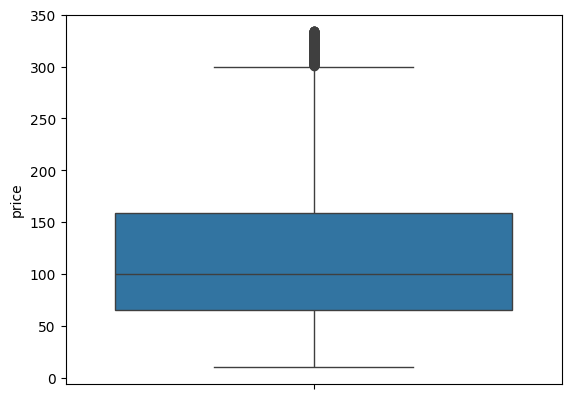

In [142]:
sns.boxplot(data = data_no_outliers,
           y='price')
plt.show()

#### After removing the outliers , the boxplot and the data looks so easy and the medain mostly falls on 100 .